In [1]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-pastel')

c:\Users\hetpe\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
df_turbido = pd.read_csv('data/Turbidostat.csv')
df_turbido

,channel,decision,time_h,OD
0,1,145,297.2658,0.3343
1,1,145,297.3492,0.3338
2,1,145,297.4325,0.3318
3,1,145,297.5158,0.3338
4,1,145,297.5992,0.3318
...,...,...,...,...
1565,8,233,321.6831,0.3462
1566,8,233,321.7678,0.3475
1567,8,233,321.8497,0.3484
1568,8,233,321.9331,0.3479


In [13]:
print(df_turbido.channel.unique())

[1 3 4 5 7 8]


In [43]:
import colorsys

def get_distinct_colors(n):
    colors = []
    for i in range(n):
        hue = i / n
        saturation = 0.65
        value = 0.85
        colors.append(colorsys.hsv_to_rgb(hue, saturation, value))
    return colors

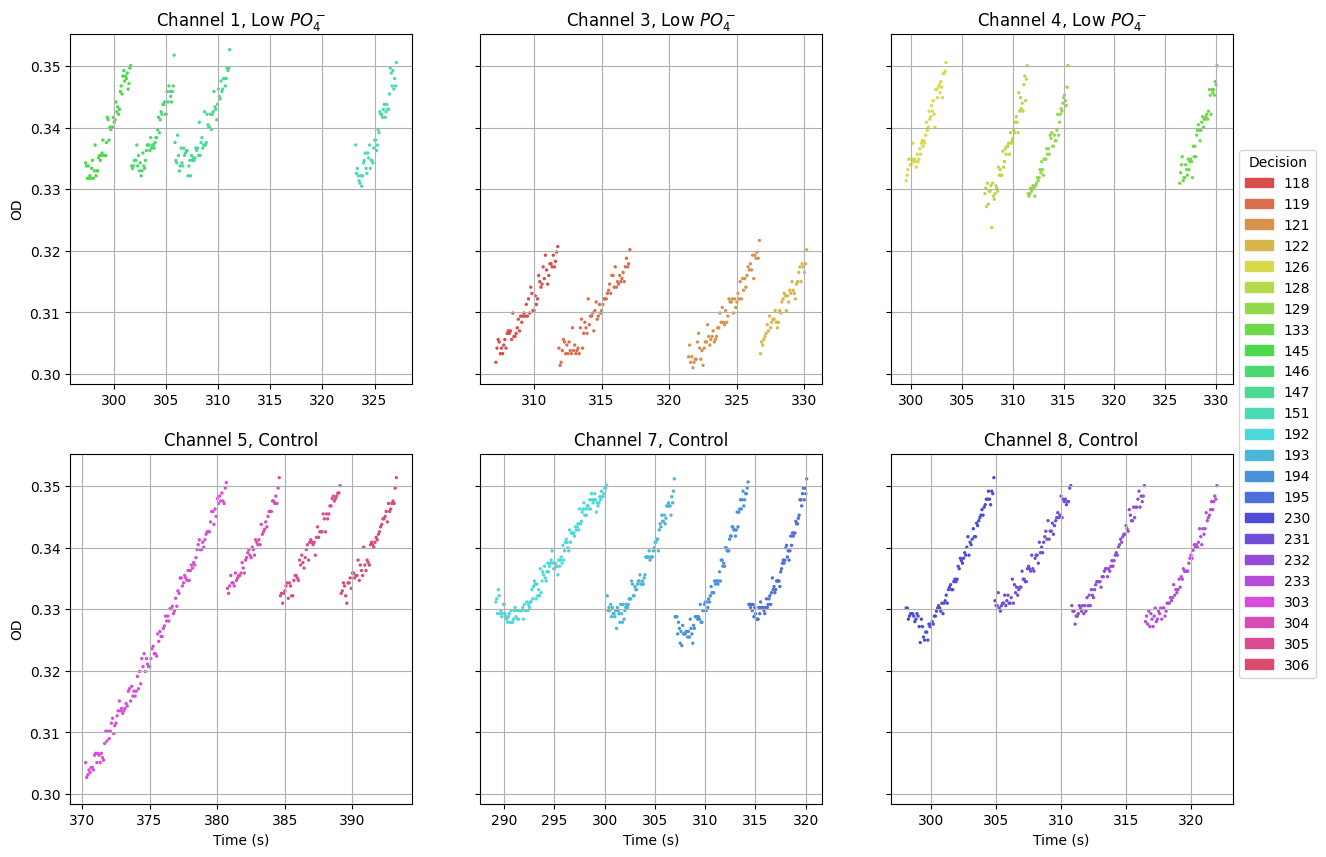

In [65]:
# df_ch1 = df_turbido[df_turbido['channel'] == 1]

import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import get_cmap

# Define fixed color mapping for all decision values
decision_values = sorted(df_turbido['decision'].unique())
# cmap = plt.get_cmap('tab10', len(decision_values))
color_map = {val: get_distinct_colors(len(decision_values))[i] for i, val in enumerate(decision_values)}


fig, axs = plt.subplots(2, 3, sharex= False, sharey= True, figsize = (15, 10))
plt.grid()

for i, channel in enumerate(sorted(df_turbido.channel.unique())):
    df = df_turbido[df_turbido['channel'] == channel]
    colors = df['decision'].map(color_map)

    if i < 3:   
        axs[0, i].scatter(df.time_h, df.OD, s = 2, c = colors, label = df.decision)
        axs[0, i].set_title(f'Channel {channel}, Low $PO_{4}^-$')
        axs[0, i].grid(True)
        if i == 0:
            axs[0, i].set_ylabel(f'OD')

    else:
        axs[1, i-3].scatter(df.time_h, df.OD, s = 2, c = colors, label = df.decision)
        axs[1, i-3].set_title(f'Channel {channel}, Control')
        axs[1, i-3].set_xlabel(f'Time (s)')
        axs[1, i-3].grid(True)
        if i-3 == 0:
            axs[1, i-3].set_ylabel(f'OD')

legend_patches = [mpatches.Patch(color=color_map[val], label=f'{val}') 
                  for val in decision_values]
fig.legend(handles=legend_patches, title='Decision', 
           loc='center left', ncol=1, bbox_to_anchor=(0.9, 0.5))
fig.tight_layout
plt.show()